# Laiko eilučių (Time Series) analizė su `flights` duomenimis

Šiame faile pateikiami pagrindiniai laiko eilučių analizės ir prognozavimo žingsniai naudojant `seaborn` rinkinį `flights`.
Pavyzdžiai orientuoti į paprastą, aiškiai interpretuojamą regresinį modelį su trendu ir sezoniškumu.

Pastaba: laiko eilučių regresija dažnai pažeidžia klasikines linijinės regresijos prielaidas (ypač paklaidų nepriklausomumą), tačiau praktikoje gali būti efektyvi kaip bazinis prognozavimo metodas.


## Bibliotekos

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Grafikai
plt.rcParams["figure.figsize"] = (10, 4)


## 1. Duomenys: kas yra laiko eilutė

Laiko eilutės duomenyse kiekviena eilutė turi atitikti **unikalų laiko momentą** (pvz., mėnesį).
`flights` duomenys jau yra mėnesinio granularumo: vienas mėnuo = viena eilutė.

Dažna klaida: bandymas taikyti laiko eilučių metodus transakciniams duomenims, kai ta pati data kartojasi daug kartų. Tokiu atveju pirmiausia reikia agreguoti iki vieno laiko vieneto.


In [2]:
flights = sns.load_dataset("flights").copy()
flights.tail()

,year,month,passengers
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
143,1960,Dec,432


## 2. Duomenų paruošimas laiko eilutei

`flights` turi `year` ir `month`, todėl sukuriamas `date` stulpelis ir nustatomas indeksas.

Gerosios praktikos:
- užtikrinti, kad duomenys būtų surikiuoti laike;
- naudoti `DatetimeIndex` su pastoviu periodiškumu (pvz., mėnesio pradžia);
- tiksliai žinoti granularumą (čia: mėnesiai).


In [3]:
# Sukuriama data (mėnesio pradžia) ir suformuojamas laiko indeksas
ts = flights.copy()

ts["date"] = pd.to_datetime(
    ts["year"].astype("int").astype("string") + "-" + ts["month"].astype("string"),
    format="%Y-%b"
)

ts = ts.sort_values("date").set_index("date")

# Vienas mėnuo = vienas taškas laike
ts = ts[["passengers"]].rename(columns={"passengers": "y"})
ts.head()


,y
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
ts.tail()


,y
date,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


### Laiko eilutės grafikas

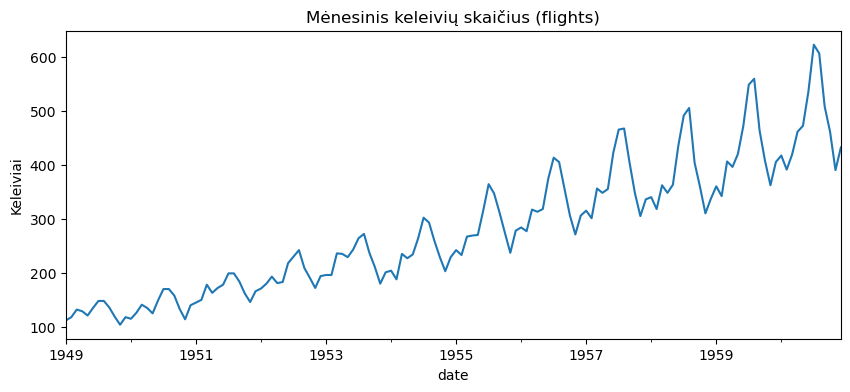

In [5]:
ts["y"].plot(title="Mėnesinis keleivių skaičius (flights)", ylabel="Keleiviai")
plt.show()

## 3. Time series analizės tipai

Dažniausi analizės tipai:
- **Išlyginimas (smoothing)**: mažinami svyravimai, kad matytųsi trendas ir dėsningumai.
- **Dekompozicija (decomposition)**: eilutė išskaidoma į trendą, sezoniškumą ir triukšmą.
- **Autokoreliacija (ACF)**: tikrinama, kokie laiko poslinkiai (lag) stipriausiai susiję su dabartimi.
- **Prognozavimas (forecasting)**: ateities reikšmių numatymas pagal istoriją.


## 4. Slankusis vidurkis (Moving Average)

Slankusis vidurkis apskaičiuoja vidurkį per pasirinktą langą (window).

Svarbu:
- didesnis langas → lygesnė kreivė, bet lėtesnė reakcija į pokyčius;
- pradžioje dažnai atsiranda `NaN`, nes nėra pakankamai ankstesnių laikotarpių.


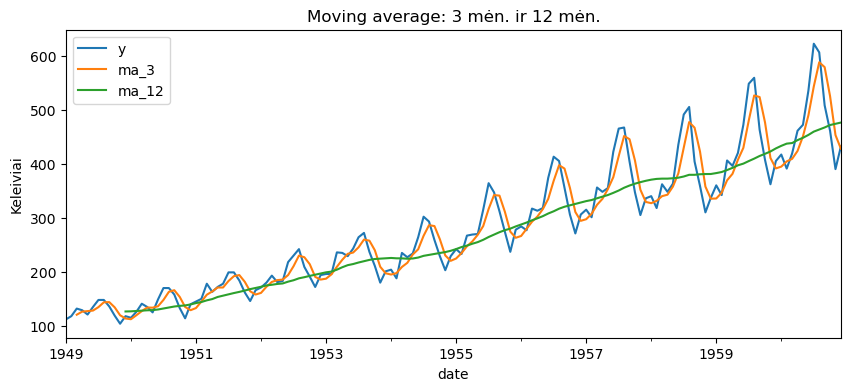

,y,ma_3,ma_12
date,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,120.666667,NaN
1949-04-01,129,126.333333,NaN
1949-05-01,121,127.333333,NaN
1949-06-01,135,128.333333,NaN
1949-07-01,148,134.666667,NaN
1949-08-01,148,143.666667,NaN
1949-09-01,136,144.000000,NaN


In [6]:
ts_ma = ts.assign(
    ma_3=ts["y"].rolling(window=3).mean(),
    ma_12=ts["y"].rolling(window=12).mean()
)

ts_ma[["y", "ma_3", "ma_12"]].plot(title="Moving average: 3 mėn. ir 12 mėn.", ylabel="Keleiviai")
plt.show()

ts_ma.head(15)

Dažna klaida: interpretuoti `ma_12` kaip „to mėnesio“ reikšmę. Iš tikrųjų tai yra **vidurkis per paskutinius 12 mėnesių** (einamasis + 11 ankstesnių).

## 5. Eksponentinis išlyginimas (Exponential Smoothing per `ewm`)

`ewm(alpha=...)` suteikia didesnį svorį naujausiems duomenims.
Skirtumas nuo slankiojo vidurkio:
- nereikia „pilno lango“, todėl paprastai **nėra `NaN` pradžioje**;
- `alpha` valdo kompromisą tarp stabilumo ir jautrumo.

Interpretacija:
- mažesnė `alpha` → lygesnė kreivė;
- didesnė `alpha` → greitesnė reakcija, bet daugiau svyravimų.


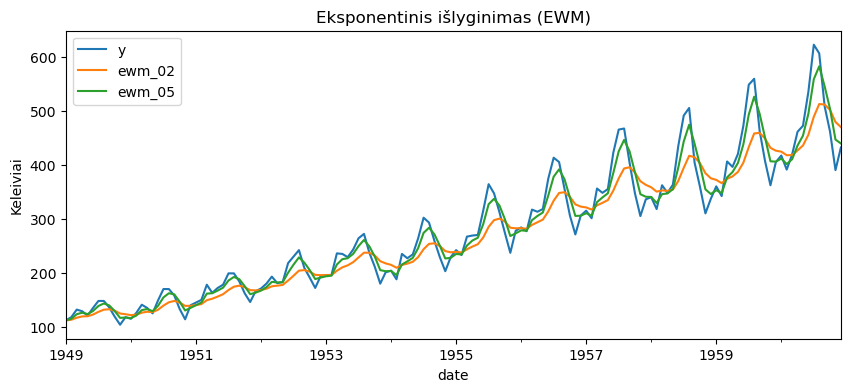

,y,ewm_02,ewm_05
date,,,
1949-01-01,112,112.0000,112.000
1949-02-01,118,113.2000,115.000
1949-03-01,132,116.9600,123.500
1949-04-01,129,119.3680,126.250
1949-05-01,121,119.6944,123.625


In [7]:
ts_ewm = ts.assign(
    ewm_02=ts["y"].ewm(alpha=0.2, adjust=False).mean(),
    ewm_05=ts["y"].ewm(alpha=0.5, adjust=False).mean()
)

ts_ewm[["y", "ewm_02", "ewm_05"]].plot(title="Eksponentinis išlyginimas (EWM)", ylabel="Keleiviai")
plt.show()

ts_ewm.head()

## 6. Dekompozicija: trendas, sezoniškumas, triukšmas

Dekompozicija padeda atskirti:
- **trendą**: ilgalaikę kryptį;
- **sezoniškumą**: pasikartojantį ciklą (čia: kas 12 mėnesių);
- **triukšmą (likučius)**: tai, ko nepaaiškina trendas ir sezoniškumas.

Svarbu:
- mėnesiniams duomenims dažniausiai naudojamas periodas `period=12`.


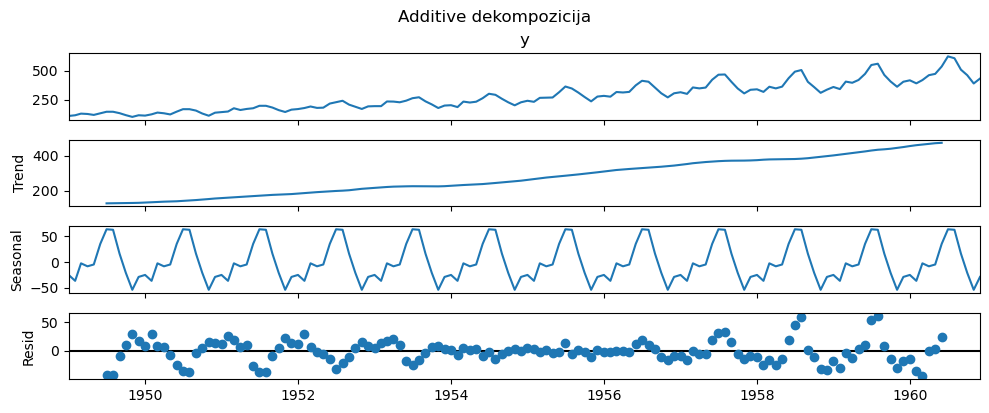

In [8]:
# Dekompozicijai patogu užtikrinti aiškų mėnesinį periodiškumą
# (mėnesio pradžia, periodas 12)
y = ts["y"].asfreq("MS")

decomp_add = seasonal_decompose(y, model="additive", period=12)
decomp_add.plot()
plt.suptitle("Additive dekompozicija", y=1.02)
plt.show()

### Dekompozicijos tipai: additive ir multiplicative

- **Additive** tinka, kai sezoniškumo amplitudė yra panaši per visą laikotarpį.
- **Multiplicative** tinka, kai sezoniškumo amplitudė didėja kartu su lygiu (augant trendui sezoniški šuoliai didėja).

`flights` dažnai geriau atitinka multiplikatyvinį elgesį (augant keleivių skaičiui didėja ir sezoniški svyravimai).


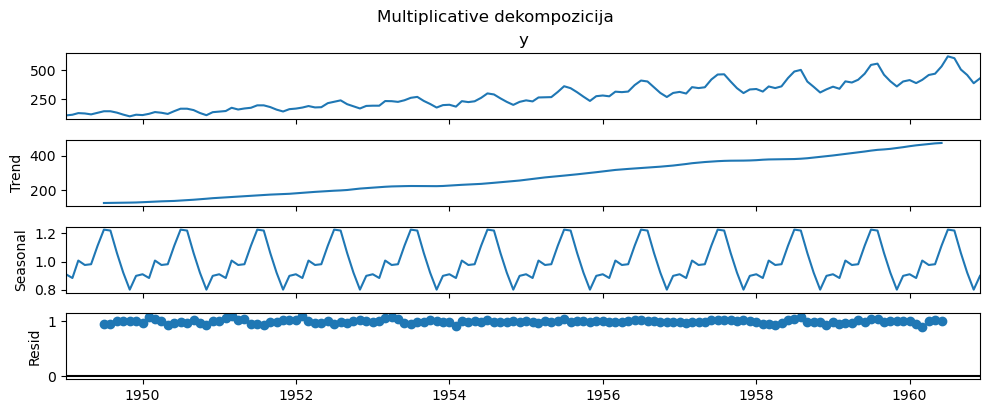

In [9]:
decomp_mul = seasonal_decompose(y, model="multiplicative", period=12)
decomp_mul.plot()
plt.suptitle("Multiplicative dekompozicija", y=1.02)
plt.show()

Gera praktika: modelio tipas parenkamas pagal likučius.
Jeigu likučiuose lieka aiškus raštas, pasirinktas modelis tikėtina netinka.


## 7. Autokoreliacijos grafikas (ACF)

ACF parodo koreliaciją tarp laiko eilutės ir jos pačios poslinkių (lag).
Mėnesiniams duomenims dažnai matomas pikas ties `lag = 12`, kuris rodo metinį sezoniškumą.


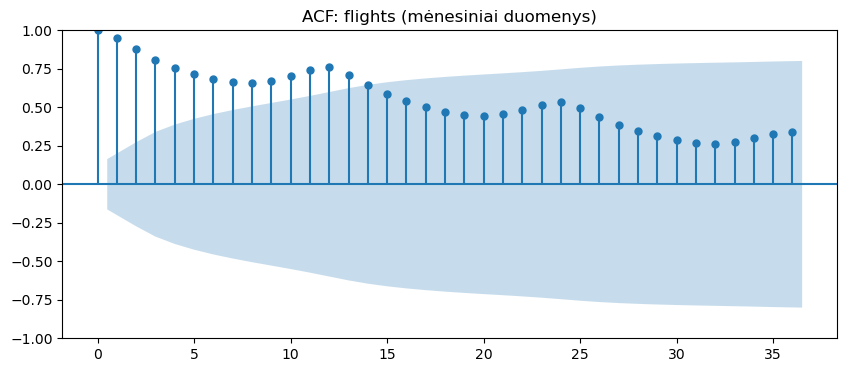

In [10]:
plot_acf(y.dropna(), lags=36)
plt.title("ACF: flights (mėnesiniai duomenys)")
plt.show()

Dažna klaida: ignoruoti trendą ir bandyti interpretuoti ACF tiesiogiai.
Esant stipriam trendui, autokoreliacijos gali būti dirbtinai didelės. Tokiu atveju naudinga diferencijacija (`diff()`), tačiau šiame pavyzdy to užtenka sezoniškumui atpažinti.


## 8. Duomenų padalijimas prognozavimui (data splitting)

Laiko eilučių atveju duomenys dalijami **pagal laiką**, ne atsitiktinai:
- ankstesnis laikotarpis → train;
- vėlesnis laikotarpis → test.

Gera praktika:
- test langas turi atitikti realų prognozavimo poreikį (pvz., 12 mėnesių).


In [11]:
# Testui paliekami paskutiniai 12 mėnesių
test_horizon = 12

train = ts.iloc[:-test_horizon].copy()
test  = ts.iloc[-test_horizon:].copy()

train.index.min(), train.index.max(), test.index.min(), test.index.max()

(Timestamp('1949-01-01 00:00:00'),
 Timestamp('1959-12-01 00:00:00'),
 Timestamp('1960-01-01 00:00:00'),
 Timestamp('1960-12-01 00:00:00'))

## 9. Linijinė regresija su trendu ir sezoniškumu

Modelio idėja:
- **trend**: seka 1, 2, 3, … (vienetas per periodą);
- **season**: mėnesių dummy kintamieji (sezoniškumas 12 mėn.).

Svarbu dėl klaidų:
- `pd.get_dummies(..., drop_first=True, dtype=float)` sukuria `float` tipo stulpelius ir padeda išvengti `ValueError` (pvz., kai `statsmodels` gauna netinkamus tipus).


In [12]:
# Paruošiami požymiai train ir test dalims
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.assign(
        trend=np.arange(1, len(out) + 1, dtype=float),
        month=out.index.month.astype("string")
    )
    # Dummy kintamieji sezoniškumui (mėnesiams); paliekama bazinė kategorija (drop_first)
    out = pd.get_dummies(out, columns=["month"], drop_first=True, dtype=float)
    return out

train_feat = make_features(train)
test_feat  = make_features(test)

train_feat.head()

,y,trend,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,
1949-01-01,112,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-02-01,118,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-03-01,132,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-04-01,129,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1949-05-01,121,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Modelio pritaikymas (fitting)

Modelis mokomas kaip įprasta OLS regresija:
- `y` – tikslinis kintamasis (keleiviai)
- `X` – trend + mėnesių dummy

Pastaba: regresijos prielaidos (ypač paklaidų nepriklausomumas) laiko eilutėse dažnai pažeidžiamos, tačiau kaip bazinis prognozavimo modelis šis metodas dažnai yra praktiškas.


In [13]:
y_train = train_feat["y"].astype(float)

X_train = train_feat.drop(columns=["y"]).astype(float)
X_train = sm.add_constant(X_train)

ols = sm.OLS(y_train, X_train).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     213.9
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.86e-74
Time:                        19:24:46   Log-Likelihood:                -597.46
No. Observations:                 132   AIC:                             1221.
Df Residuals:                     119   BIC:                             1258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.1629      7.827      8.836      0.000      53.664      84.662
trend          2.5681      0.054     47.546      0.000       2.461       2.675
month_10      -0.0222     10.053     -0.002      0.998     -19.928      19.884
month_11     -32.9539     10.056     -3.277      0.001     -52.865     -13.042
month_12      -7.7039     10.059     -0.766      0.445     -27.621      12.214
month_2       -7.5681     10.041     -0.754      0.453     -27.451      12.315
month_3       25.6819     10.042      2.557      0.012       5.798      45.566
month_4       15.9320     10.043      1.586      0.115      -3.953      35.817
month_5       17.5457     10.044      1.747      0.083      -2.342      37.433
month_6       52.7049     10.045      5.247      0.000      32.815      72.595
month_7       85.5004     10.046      8.510      0.000      65.607     105.393
month_8       84.1141     10.048      8.371      0.000      64.217     104.011
month_9       37.3641     10.051      3.718      0.000      17.463      57.265
==============================================================================
Omnibus:                       12.703   Durbin-Watson:                   0.458
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.363
Skew:                           0.725   Prob(JB):                      0.00125
Kurtosis:                       3.573   Cond. No.                         955.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Koeficientų interpretacija (paprastai)

- `trend` koeficientas parodo vidutinį keleivių pokytį per 1 mėnesį, jei sezoniškumas nekinta.
- Mėnesio dummy koeficientai rodo skirtumą nuo bazinio mėnesio (tas mėnuo, kuris „išmestas“ dėl `drop_first=True`).

Dažna klaida: pamiršti, kad dummy koeficientai yra **palyginimas su baze**, o ne absoliutus sezoniškumo dydis.


## 10. Prognozė test laikotarpiui (forecasting)

Prognozė skaičiuojama test periodui, naudojant tas pačias požymių taisykles kaip train daliai.


In [14]:
X_test = test_feat.drop(columns=["y"]).astype(float)
X_test = sm.add_constant(X_test)

test_pred = ols.predict(X_test)

result = test.copy()
result["pred"] = test_pred.values
result.head()

,y,pred
date,,
1960-01-01,417,71.731061
1960-02-01,391,66.731061
1960-03-01,419,102.549242
1960-04-01,461,95.367424
1960-05-01,472,99.549242


### Faktinės ir prognozuotos reikšmės

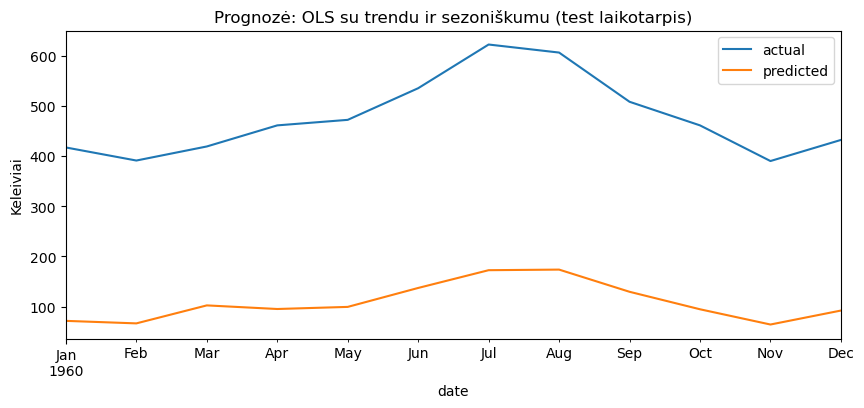

In [15]:
result[["y", "pred"]].rename(columns={"y":"actual", "pred":"predicted"}).plot(
    title="Prognozė: OLS su trendu ir sezoniškumu (test laikotarpis)",
    ylabel="Keleiviai"
)
plt.show()

## 11. Modelio įvertinimas (scoring): MAE ir MAPE

- **MAE**: vidutinė absoliuti paklaida (keleivių vienetais).
- **MAPE**: vidutinė absoliuti procentinė paklaida.

Svarbu:
- MAPE gali būti problemiškas, kai faktinės reikšmės arti nulio. Šiame rinkinyje tai nėra problema.


In [16]:
mae = mean_absolute_error(result["y"], result["pred"])
mape = mean_absolute_percentage_error(result["y"], result["pred"])

mae, mape

(367.7613636363635, 0.7778365844493496)

Interpretacija:
- MAE parodo, kiek vidutiniškai modelis klysta keleivių skaičiumi.
- MAPE parodo, kiek vidutiniškai modelis klysta procentais, todėl patogu lyginti skirtingų mastelių laikotarpius ar rodiklius.


## 12. Dažnos klaidos ir gerosios praktikos (santrauka)

Dažnos klaidos:
- atsitiktinis train/test padalijimas (time series atveju tai sukelia informacijos nutekėjimą);
- netinkamas granularumas (pvz., maišomi dieniniai ir mėnesiniai duomenys);
- `object` tipo dummy stulpeliai (vėliau sukelia `ValueError` modeliuojant);
- per ilga prognozė be realaus poreikio (toliau į ateitį – mažesnis tikslumas);
- sezoniškumo ignoravimas (modelis pagauna trendą, bet sistemingai klysta cikle).

Gerosios praktikos:
- aiškiai nuspręsti laiko vienetą (mėnuo, savaitė, diena) pagal verslo sprendimą;
- vizualizuoti laiko eilutę prieš modeliavimą;
- naudoti išlyginimą (moving average, ewm) dėsningumams pamatyti;
- dekompozicija ir ACF padeda patikrinti sezoniškumo periodą;
- kurti `trend` ir sezoniškumo dummy su aiškiais tipais (`dtype=float`).
